In [ ]:
import json
import os
import shutil
import time

# 1. 경로 설정 (사용자 환경에 맞게 수정하세요)
json_dir = "./data"             # 모든 json 파일이 모여있는 폴더 경로
video_folders_root = "./data"   # 이미지 폴더들이 모여있는 상위 폴더 경로

# 최종적으로 생성될 YOLO 표준 데이터셋 구조 경로
dataset_root = "./dataset/train"
output_image_dir = os.path.join(dataset_root, "images")
output_label_dir = os.path.join(dataset_root, "labels")

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

# 2. JSON 파일 목록 추출
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
total_videos = len(json_files)
print(f"==================================================")
print(f"🚀 총 {total_videos}개의 JSON 기반 매칭 및 전처리를 시작합니다.")
print(f"==================================================")

start_time = time.time()  # 전체 소요 시간 측정용

for idx, json_file in enumerate(json_files, 1):
    json_path = os.path.join(json_dir, json_file)
    
    # 1. 원본 파일 기본 이름 구하기
    # 예: "20201022_dog-bodylower-000028.mp4.json" -> "20201022_dog-bodylower-000028.mp4"
    base_name_with_mp4 = os.path.splitext(json_file)[0]
    # 예: "20201022_dog-bodylower-000028.mp4" -> "20201022_dog-bodylower-000028"
    base_name_without_mp4 = base_name_with_mp4.replace(".mp4", "")
    
    # 2. 다형성 폴더 매칭 기법 적용
    # 후보 1: 뒤에 .mp4가 붙은 폴더 경로
    path_candidate1 = os.path.join(video_folders_root, base_name_with_mp4)
    # 후보 2: 뒤에 .mp4가 붙지 않은 폴더 경로
    path_candidate2 = os.path.join(video_folders_root, base_name_without_mp4)
    
    src_video_folder_path = None
    video_folder_name = ""
    
    # 실제로 존재하는 폴더를 선택합니다.
    if os.path.exists(path_candidate1) and os.path.isdir(path_candidate1):
        src_video_folder_path = path_candidate1
        video_folder_name = base_name_with_mp4
    elif os.path.exists(path_candidate2) and os.path.isdir(path_candidate2):
        src_video_folder_path = path_candidate2
        video_folder_name = base_name_without_mp4
        
    # 만약 둘 다 없다면 에러를 내지 않고 경고 후 다음 JSON으로 넘어갑니다.
    if src_video_folder_path is None:
        print(f"\n⚠️  [{idx}/{total_videos}] 매칭 실패: '{base_name_without_mp4}'에 맞는 이미지 폴더를 찾을 수 없습니다. (건너뜀)")
        continue

    # 매칭 성공 시 진행 상황 출력
    print(f"\n🎬 [{idx}/{total_videos}] 매칭 성공 및 처리 중: {video_folder_name}")

    # JSON 데이터 로드
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 해상도 동적 추출
    metadata = data.get("metadata", {})
    IMG_W = metadata.get("width", 720)
    IMG_H = metadata.get("height", 1280)

    annotations = data.get("annotations", [])
    total_frames = len(annotations)
    processed_frame_count = 0

    # 각 프레임 데이터 처리
    for ann_idx, ann in enumerate(annotations, 1):
        frame_num = ann["frame_number"]
        timestamp = ann.get("timestamp", 0)
        
        # 이미지 파일명 규칙 정의 (frame_0_timestamp_0.jpg)
        original_img_name = f"frame_{frame_num}_timestamp_{timestamp}.jpg"
        src_image_path = os.path.join(src_video_folder_path, original_img_name)
        
        # 실제로 이미지 파일이 해당 폴더에 존재하는지 한 번 더 체크
        if not os.path.exists(src_image_path):
            continue

        # 중복 방지를 위한 고유 파일 이름 생성 (폴더명을 접두사로 결합)
        unique_file_base = f"{video_folder_name}_{original_img_name[:-4]}"
        new_img_name = f"{unique_file_base}.jpg"
        new_txt_name = f"{unique_file_base}.txt"

        # 1. Bounding Box 정규화 및 YOLO 라벨 스트링 생성
        bbox = ann.get("bounding_box")
        if bbox is None:
            continue
            
        x_center = (bbox["x"] + bbox["width"] / 2) / IMG_W
        y_center = (bbox["y"] + bbox["height"] / 2) / IMG_H
        w = bbox["width"] / IMG_W
        h = bbox["height"] / IMG_H
        
        yolo_line = f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
        
        # 2. Keypoints 추출
        keypoints_data = ann.get("keypoints", {})
        for kp_idx in range(1, 16):
            kp = keypoints_data.get(str(kp_idx))
            if kp == "null" or kp is None:
                yolo_line += " 0.000000 0.000000 0"
            else:
                kp_x = kp["x"] / IMG_W
                kp_y = kp["y"] / IMG_H
                yolo_line += f" {kp_x:.6f} {kp_y:.6f} 2"

        # 3. 파일 저장 및 복사 수행
        # 3-1. YOLO 라벨(.txt) 저장
        dst_txt_path = os.path.join(output_label_dir, new_txt_name)
        with open(dst_txt_path, "w", encoding="utf-8") as out_f:
            out_f.write(yolo_line)
            
        # 3-2. 원본 이미지(.jpg)를 최종 images 폴더로 복사
        dst_img_path = os.path.join(output_image_dir, new_img_name)
        shutil.copy(src_image_path, dst_img_path)
        
        processed_frame_count += 1
        
        # 50프레임마다 한 번씩 프레임 진행률 출력
        if ann_idx % 50 == 0 or ann_idx == total_frames:
            print(f"   └ 🔄 프레임 변환 중... ({ann_idx}/{total_frames})")

    print(f"   ✅ 완료: 총 {processed_frame_count}장의 이미지/라벨 매칭 성공")

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\n==================================================")
print(f"🎉 모든 폴더의 매칭 작업 및 YOLO 데이터셋 통합이 완료되었습니다!")
print(f"⏱️ 총 소요 시간: {elapsed_time:.2f}초")
print(f"==================================================")

🚀 총 39537개의 JSON 기반 매칭 및 전처리를 시작합니다.

🎬 [1/39537] 매칭 성공 및 처리 중: 20201022_dog-bodylower-000028.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [2/39537] 매칭 성공 및 처리 중: 20201022_dog-feetup-000029.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [3/39537] 매칭 성공 및 처리 중: 20201022_dog-footup-000023.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [4/39537] 매칭 성공 및 처리 중: 20201022_dog-footup-000026.mp4
   ✅ 완료: 총 13장의 이미지/라벨 매칭 성공

🎬 [5/39537] 매칭 성공 및 처리 중: 20201022_dog-lying-000021.mp4
   ✅ 완료: 총 13장의 이미지/라벨 매칭 성공

🎬 [6/39537] 매칭 성공 및 처리 중: 20201022_dog-lying-000036.mp4
   ✅ 완료: 총 13장의 이미지/라벨 매칭 성공

🎬 [7/39537] 매칭 성공 및 처리 중: 20201023_dog-bodylower-000041.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [8/39537] 매칭 성공 및 처리 중: 20201023_dog-bodylower-000042.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [9/39537] 매칭 성공 및 처리 중: 20201023_dog-sit-000043.mp4
   ✅ 완료: 총 13장의 이미지/라벨 매칭 성공

🎬 [10/39537] 매칭 성공 및 처리 중: 20201024_dog-bodylower-000062.mp4
   ✅ 완료: 총 14장의 이미지/라벨 매칭 성공

🎬 [11/39537] 매칭 성공 및 처리 중: 20201024_dog-bodylower-000159.mp4
   ✅ 완료: 총 14장의 이미지/라벨 

In [ ]:
import json
import os
import shutil
import time

# 1. 경로 설정 (사용자 환경에 맞게 수정하세요)
json_dir = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\반려동물 구분을 위한 동물 영상\Validation\DOG"             # 모든 json 파일이 모여있는 폴더 경로
video_folders_root = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\반려동물 구분을 위한 동물 영상\Validation\DOG"   # 이미지 폴더들이 모여있는 상위 폴더 경로

# 최종적으로 생성될 YOLO 표준 데이터셋 구조 경로
dataset_root = "./dataset/val"
output_image_dir = os.path.join(dataset_root, "images")
output_label_dir = os.path.join(dataset_root, "labels")

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

# 2. JSON 파일 목록 추출
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
total_videos = len(json_files)
print(f"==================================================")
print(f"🚀 총 {total_videos}개의 JSON 기반 매칭 및 전처리를 시작합니다.")
print(f"==================================================")

start_time = time.time()  # 전체 소요 시간 측정용

for idx, json_file in enumerate(json_files, 1):
    json_path = os.path.join(json_dir, json_file)
    
    # 1. 원본 파일 기본 이름 구하기
    # 예: "20201022_dog-bodylower-000028.mp4.json" -> "20201022_dog-bodylower-000028.mp4"
    base_name_with_mp4 = os.path.splitext(json_file)[0]
    # 예: "20201022_dog-bodylower-000028.mp4" -> "20201022_dog-bodylower-000028"
    base_name_without_mp4 = base_name_with_mp4.replace(".mp4", "")
    
    # 2. 다형성 폴더 매칭 기법 적용
    # 후보 1: 뒤에 .mp4가 붙은 폴더 경로
    path_candidate1 = os.path.join(video_folders_root, base_name_with_mp4)
    # 후보 2: 뒤에 .mp4가 붙지 않은 폴더 경로
    path_candidate2 = os.path.join(video_folders_root, base_name_without_mp4)
    
    src_video_folder_path = None
    video_folder_name = ""
    
    # 실제로 존재하는 폴더를 선택합니다.
    if os.path.exists(path_candidate1) and os.path.isdir(path_candidate1):
        src_video_folder_path = path_candidate1
        video_folder_name = base_name_with_mp4
    elif os.path.exists(path_candidate2) and os.path.isdir(path_candidate2):
        src_video_folder_path = path_candidate2
        video_folder_name = base_name_without_mp4
        
    # 만약 둘 다 없다면 에러를 내지 않고 경고 후 다음 JSON으로 넘어갑니다.
    if src_video_folder_path is None:
        print(f"\n⚠️  [{idx}/{total_videos}] 매칭 실패: '{base_name_without_mp4}'에 맞는 이미지 폴더를 찾을 수 없습니다. (건너뜀)")
        continue

    # 매칭 성공 시 진행 상황 출력
    print(f"\n🎬 [{idx}/{total_videos}] 매칭 성공 및 처리 중: {video_folder_name}")

    # JSON 데이터 로드
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 해상도 동적 추출
    metadata = data.get("metadata", {})
    IMG_W = metadata.get("width", 720)
    IMG_H = metadata.get("height", 1280)

    annotations = data.get("annotations", [])
    total_frames = len(annotations)
    processed_frame_count = 0

    # 각 프레임 데이터 처리
    for ann_idx, ann in enumerate(annotations, 1):
        frame_num = ann["frame_number"]
        timestamp = ann.get("timestamp", 0)
        
        # 이미지 파일명 규칙 정의 (frame_0_timestamp_0.jpg)
        original_img_name = f"frame_{frame_num}_timestamp_{timestamp}.jpg"
        src_image_path = os.path.join(src_video_folder_path, original_img_name)
        
        # 실제로 이미지 파일이 해당 폴더에 존재하는지 한 번 더 체크
        if not os.path.exists(src_image_path):
            continue

        # 중복 방지를 위한 고유 파일 이름 생성 (폴더명을 접두사로 결합)
        unique_file_base = f"{video_folder_name}_{original_img_name[:-4]}"
        new_img_name = f"{unique_file_base}.jpg"
        new_txt_name = f"{unique_file_base}.txt"

        # 1. Bounding Box 정규화 및 YOLO 라벨 스트링 생성
        bbox = ann.get("bounding_box")
        if bbox is None:
            continue
            
        x_center = (bbox["x"] + bbox["width"] / 2) / IMG_W
        y_center = (bbox["y"] + bbox["height"] / 2) / IMG_H
        w = bbox["width"] / IMG_W
        h = bbox["height"] / IMG_H
        
        yolo_line = f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
        
        # 2. Keypoints 추출
        keypoints_data = ann.get("keypoints", {})
        for kp_idx in range(1, 16):
            kp = keypoints_data.get(str(kp_idx))
            if kp == "null" or kp is None:
                yolo_line += " 0.000000 0.000000 0"
            else:
                kp_x = kp["x"] / IMG_W
                kp_y = kp["y"] / IMG_H
                yolo_line += f" {kp_x:.6f} {kp_y:.6f} 2"

        # 3. 파일 저장 및 복사 수행
        # 3-1. YOLO 라벨(.txt) 저장
        dst_txt_path = os.path.join(output_label_dir, new_txt_name)
        with open(dst_txt_path, "w", encoding="utf-8") as out_f:
            out_f.write(yolo_line)
            
        # 3-2. 원본 이미지(.jpg)를 최종 images 폴더로 복사
        dst_img_path = os.path.join(output_image_dir, new_img_name)
        shutil.copy(src_image_path, dst_img_path)
        
        processed_frame_count += 1
        
        # 50프레임마다 한 번씩 프레임 진행률 출력
        if ann_idx % 50 == 0 or ann_idx == total_frames:
            print(f"   └ 🔄 프레임 변환 중... ({ann_idx}/{total_frames})")

    print(f"   ✅ 완료: 총 {processed_frame_count}장의 이미지/라벨 매칭 성공")

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\n==================================================")
print(f"🎉 모든 폴더의 매칭 작업 및 YOLO 데이터셋 통합이 완료되었습니다!")
print(f"⏱️ 총 소요 시간: {elapsed_time:.2f}초")
print(f"==================================================")

In [ ]:
import os
from ultralytics import YOLO

if __name__ == "__main__":
    print("\n🚀 YOLOv8 Pose 모델 학습을 시작합니다...")

    project_name = "Dog_Pose_Project"
    experiment_name = "yolov8_dog_pose"
    
    # YOLOv8 포즈 기본 사전학습 모델 로드
    model = YOLO("yolov8m-pose.pt")
    
    # 모델 학습 시작
    model.train(
        data=r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\dataset.yaml",         # 생성한 data.yaml 경로
        epochs=2,               # 학습 에포크 수
        imgsz=320,              # 입력 이미지 크기
        batch=32,               # 배치 크기
        device=0,               # 사용할 GPU 번호
        workers=8,              # 데이터 로드용 멀티프로세스 CPU 코어 수
        project=project_name,   # 결과가 저장될 상위 폴더
        name=experiment_name,   # 현재 실험 폴더 이름
        exist_ok=True,          # 폴더가 이미 있어도 덮어쓰거나 이어서 저장
        pretrained=True         # 사전 학습된 가중치(Pretrained weight) 활용
    )
    
    print("\n🎉 모델 학습이 완료되었습니다!")

    # ==================================================
    # 4. 검증 데이터셋을 통한 정밀 평가 (Validation)
    # ==================================================
    print("\n🔍 검증 데이터셋(Val)을 통해 최종 성능 평가를 시작합니다...")
    
    # 학습이 끝난 후 가장 성능이 좋았던 베스트 가중치 파일로 평가 진행
    best_model_path = os.path.join(project_name, experiment_name, "weights", "best.pt")
    trained_model = YOLO(best_model_path)
    
    # 검증 수행 (mAP50, mAP50-95 지표 산출)
    metrics = trained_model.val()
    
    print("\n==================================================")
    print("📊 [최종 검증 지표 결과 요약]")
    print(f"🔹 Box mAP50 (바운딩박스 정확도): {metrics.box.map50:.4f}")
    print(f"🔹 Pose mAP50 (관절 위치 정확도): {metrics.pose.map50:.4f}")
    print("==================================================")


🚀 YOLOv8 Pose 모델 학습을 시작합니다...
New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.11.9 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-pose.pt, momentum=

In [ ]:
from ultralytics import YOLO

# 1. 이전 학습에서 저장된 가중치 파일 경로 지정
model_path = 'C:/Project/Python_Source/AI01/runs/pose/Dog_Pose_Project/yolov8_dog_pose/weights/last.pt'

# 2. 모델 로드
model = YOLO(model_path)

# 3. 추가 학습
model.train(
    data='./dataset/data.yaml',
    imgsz=320,              # 입력 이미지 크기
    batch=32,               # 배치 크기
    device=0,               # 사용할 GPU 번호
    workers=8,
    name='Dog_Pose_Project',
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.11.9 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:/Project/Python_Source/AI01/runs/pose/Dog_Pose_Projec

In [ ]:
print("hello")

In [2]:
from ultralytics import YOLO
trained_model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")
    
# 검증 수행 (mAP50, mAP50-95 지표 산출)
metrics = trained_model.val()

print("\n==================================================")
print("📊 [최종 검증 지표 결과 요약]")
print(f"🔹 Box mAP50 (바운딩박스 정확도): {metrics.box.map50:.4f}")
print(f"🔹 Pose mAP50 (관절 위치 정확도): {metrics.pose.map50:.4f}")
print("==================================================")

Ultralytics 8.4.48  Python-3.11.9 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv8m-pose summary (fused): 102 layers, 26,407,114 parameters, 0 gradients, 80.9 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 91.941.4 MB/s, size: 50.0 KB)
val: Scanning C:\Project\Python_Source\AI01\mini_project_08\dataset\val\labels.cache... 388429 images, 0 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 388429/388429  0.0s
val: C:\Project\Python_Source\AI01\mini_project_08\dataset\val\images\20201202_dog-bodylower-007784.mp4_frame_522_timestamp_17400.jpg: ignoring corrupt image/label: negative class labels or coordinate [  -0.022222]
val: C:\Project\Python_Source\AI01\mini_project_08\dataset\val\images\20201202_dog-walkrun-004026.mp4_frame_228_timestamp_7600.jpg: ignoring corrupt image/label: negative class labels or coordinate [   -0.14931]
val: C:\Project\Python_Source\AI01\mini_project_08\dataset\val\images\20201202_dog-walkrun-004026.mp4_frame_618_timestamp_20600.jpg: 


image 1/1 C:\Project\Python_Source\AI01\mini_project_08\dataset\val\images\20201202_dog-bodylower-007784.mp4_frame_522_timestamp_17400.jpg: 320x256 1 dog, 37.6ms
Speed: 2.1ms preprocess, 37.6ms inference, 2.4ms postprocess per image at shape (1, 3, 320, 256)


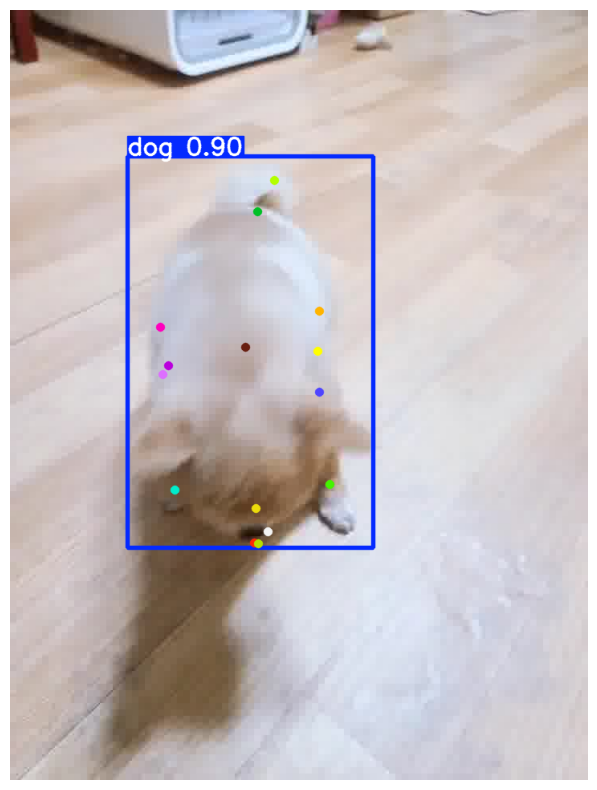

In [4]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. 기존에 검증에 사용하셨던 모델 로드
model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")

# 2. 테스트할 이미지 경로 설정 
# (에러가 나면 아래 경로를 현재 가지고 계신 실제 이미지 파일 경로로 수정해 주세요)
test_image_path = r"C:\Project\Python_Source\AI01\mini_project_08\dataset\val\images\20201202_dog-bodylower-007784.mp4_frame_522_timestamp_17400.jpg"

# 3. 모델 추론 수행 (시각화 결과를 쉽게 보기 위해 conf_threshold 지정)
results = model.predict(source=test_image_path, conf=0.5, save=False)

# 4. 예측 결과가 그려진 이미지 추출 (기본 내부 시각화 기능 활용)
# results[0].plot()은 바운딩 박스와 키포인트가 그려진 BGR 넘파이 배열을 반환합니다.
annotated_frame = results[0].plot()

# 5. OpenCV(BGR) 이미지를 Matplotlib(RGB) 포맷으로 변환 후 출력
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_frame_rgb)
plt.axis("off")  # 축 숨기기
plt.show()

In [7]:
import cv2
import os
from ultralytics import YOLO

# 1. 기존에 학습된 모델 로드
model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")

# 2. 입력 동영상 및 결과 동영상 경로 설정
# (환경에 맞게 실제 동영상 파일 경로로 수정해 주세요)
input_video_path = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\videoplayback1.mp4"
output_video_path = "./output_dog_pose2.mp4"

# 3. OpenCV를 이용한 동영상 파일 열기
cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
    print(f"❌ 동영상을 열 수 없습니다. 경로를 확인해 주세요: {input_video_path}")
else:
    # 동영상 속성(가로, 세로, FPS) 가져오기
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # MP4 파일 저장을 위한 VideoWriter 설정 (Windows/Linux 범용 MP4v 코덱 사용)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"🎬 동영상 분석 시작 (총 프레임 수: {total_frames})")
    
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # 동영상이 끝나면 반복문 종료
            
        # 모델 추론 수행 (프레임별 예측)
        # verbose=False로 설정하여 터미널에 불필요한 로그가 너무 많이 찍히는 것을 방지합니다.
        results = model.predict(source=frame, conf=0.5, verbose=False)
        
        # 예측 결과(바운딩 박스 및 스켈레톤 키포인트)가 그려진 프레임 추출
        annotated_frame = results[0].plot()
        
        # 결과 동영상 파일에 프레임 쓰기
        out.write(annotated_frame)
        
        frame_count += 1
        if frame_count % 30 == 0 or frame_count == total_frames:
            print(f"🔄 동영상 변환 중... ({frame_count} / {total_frames})")

    # 사용한 자원 해제
    cap.release()
    out.release()
    print(f"🎉 동영상 처리가 완료되었습니다! 저장된 경로: {output_video_path}")

🎬 동영상 분석 시작 (총 프레임 수: 4652)
🔄 동영상 변환 중... (30 / 4652)
🔄 동영상 변환 중... (60 / 4652)
🔄 동영상 변환 중... (90 / 4652)
🔄 동영상 변환 중... (120 / 4652)
🔄 동영상 변환 중... (150 / 4652)
🔄 동영상 변환 중... (180 / 4652)
🔄 동영상 변환 중... (210 / 4652)
🔄 동영상 변환 중... (240 / 4652)
🔄 동영상 변환 중... (270 / 4652)
🔄 동영상 변환 중... (300 / 4652)
🔄 동영상 변환 중... (330 / 4652)
🔄 동영상 변환 중... (360 / 4652)
🔄 동영상 변환 중... (390 / 4652)
🔄 동영상 변환 중... (420 / 4652)
🔄 동영상 변환 중... (450 / 4652)
🔄 동영상 변환 중... (480 / 4652)
🔄 동영상 변환 중... (510 / 4652)
🔄 동영상 변환 중... (540 / 4652)
🔄 동영상 변환 중... (570 / 4652)
🔄 동영상 변환 중... (600 / 4652)
🔄 동영상 변환 중... (630 / 4652)
🔄 동영상 변환 중... (660 / 4652)
🔄 동영상 변환 중... (690 / 4652)
🔄 동영상 변환 중... (720 / 4652)
🔄 동영상 변환 중... (750 / 4652)
🔄 동영상 변환 중... (780 / 4652)
🔄 동영상 변환 중... (810 / 4652)
🔄 동영상 변환 중... (840 / 4652)
🔄 동영상 변환 중... (870 / 4652)
🔄 동영상 변환 중... (900 / 4652)
🔄 동영상 변환 중... (930 / 4652)
🔄 동영상 변환 중... (960 / 4652)
🔄 동영상 변환 중... (990 / 4652)
🔄 동영상 변환 중... (1020 / 4652)
🔄 동영상 변환 중... (1050 / 4652)
🔄 동영상 변환 중... (1080 / 4652)


In [1]:
import os
import glob
import json
import numpy as np
import torch
from torch.utils.data import Dataset

class DogEmotionTrainTimeSeriesDataset(Dataset):
    def __init__(self, data_dir, sequence_length=30):
        self.sequence_length = sequence_length
        self.emotion_map = {"행복/즐거움": 0, "편안/안정": 1, "화남/불쾌": 2, "불안/슬픔": 3}
        self.json_files = glob.glob(os.path.join(data_dir, "*.json"))
        self.samples = []
        
        for file_path in self.json_files:
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                except:
                    continue
            raw_emotion = data.get("metadata", {}).get("inspect", {}).get("emotion", "행복/즐거움")
            label = self.emotion_map.get(raw_emotion, -1)
            if label == -1: continue
            
            annotations = data.get("annotations", [])
            if len(annotations) >= sequence_length:
                for start_frame in range(len(annotations) - sequence_length + 1):
                    self.samples.append((file_path, start_frame, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start_frame, label = self.samples[idx]
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        annotations = data["annotations"][start_frame : start_frame + self.sequence_length]
        
        sequence_kp = []
        for ann in annotations:
            kp_dict = ann.get("keypoints", {})
            frame_kp = []
            for i in range(1, 16):
                str_i = str(i)
                if kp_dict and str_i in kp_dict and isinstance(kp_dict[str_i], dict):
                    frame_kp.extend([kp_dict[str_i].get("x", 0.0), kp_dict[str_i].get("y", 0.0)])
                else:
                    frame_kp.extend([0.0, 0.0])
            sequence_kp.append(frame_kp)
        return torch.tensor(sequence_kp, dtype=torch.float32) / 2000.0, torch.tensor(label, dtype=torch.long)

# 경로(VAL_DIRECTORY)는 본인의 실제 검증 데이터 폴더 경로로 정확히 수정해 주세요.
TRAIN_DIRECTORY = r"C:\Project\Python_Source\AI01\mini_project_08\data"

# 데이터셋 객체 생성
train_dataset = DogEmotionTrainTimeSeriesDataset(TRAIN_DIRECTORY, sequence_length=30)
print("✅ val_dataset이 성공적으로 생성되었습니다!")

✅ val_dataset이 성공적으로 생성되었습니다!


In [3]:
X_final, y_final = [], []
print("💾 데이터 고속도로 개통 중 (한 번만 하면 됩니다)...")
for i in range(len(train_dataset)):
    kp, lbl = train_dataset[i]
    X_final.append(kp.numpy())
    y_final.append(lbl.item())

# 저장
np.save("X_data.npy", np.array(X_final))
np.save("y_data.npy", np.array(y_final))
print("✅ 저장 완료!")

💾 데이터 고속도로 개통 중 (한 번만 하면 됩니다)...
✅ 저장 완료! 이제부터는 로딩 시간이 거의 0초입니다.


In [1]:
import numpy as np

# y_data.npy 파일 로드
y_data = np.load("y_data.npy")

# 각 클래스별 고유 값과 개수 확인
unique, counts = np.unique(y_data, return_counts=True)

# 결과 출력
print("클래스별 데이터 분포:")
for label, count in zip(unique, counts):
    print(f"클래스 {label}: {count}개")

클래스별 데이터 분포:
클래스 0: 968974개
클래스 1: 1562626개
클래스 2: 84192개
클래스 3: 146352개


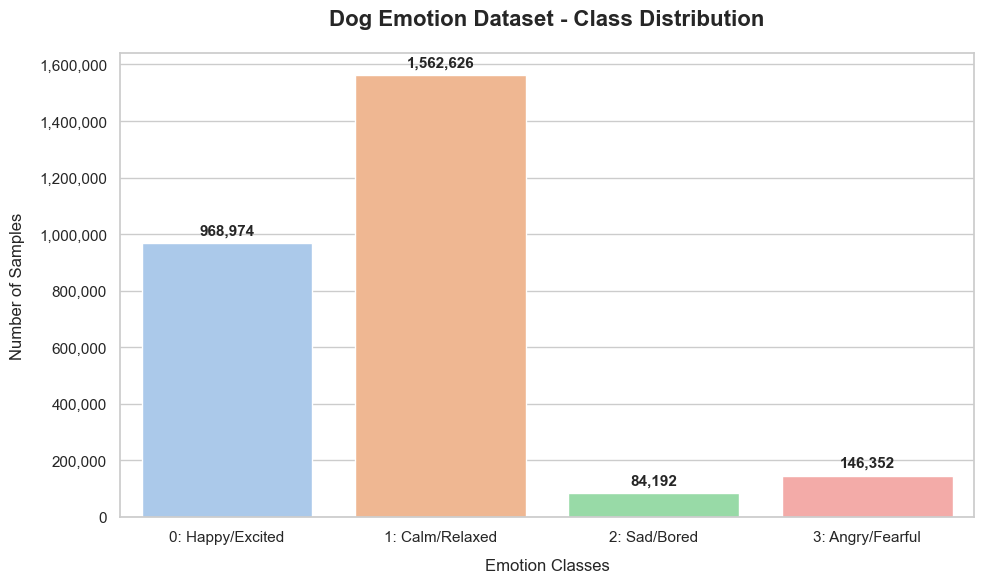

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 기존에 세팅된 y_data.npy 로드 (이미 하셨다면 생략 가능)
y_data = np.load("y_data.npy")

# 2. 클래스별 고유 값과 개수 카운트
unique, counts = np.unique(y_data, return_counts=True)

# 3. 시각화에 표시할 감정 레이블 정의 (사분면 기준 명칭)
emotion_labels = [
    "0: Happy/Excited",
    "1: Calm/Relaxed",
    "2: Sad/Bored",
    "3: Angry/Fearful"
]

# 실제 데이터에 존재하는 클래스 개수만큼 레이블 슬라이싱 (4개 혹은 5개 분기에 대응)
labels = emotion_labels[:len(unique)]

# 4. 스타일 및 그래프 크기 설정
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 한글 깨짐 방지 설정 (필요 시 주석 해제하여 사용)
# plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용
plt.rcParams['axes.unicode_minus'] = False

# 5. 바 차트 그리는 부분
palette = sns.color_scheme = "pastel" # 부드러운 파스텔 톤 색상 적용
ax = sns.barplot(x=labels, y=counts, hue=labels, legend=False, palette=palette)

# 6. 각 막대 그래프 위에 실제 데이터 개수(숫자) 텍스트 표시하기
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                weight='bold')

# 7. 그래프 타이틀 및 축 이름 설정
plt.title("Dog Emotion Dataset - Class Distribution", fontsize=16, pad=20, weight='bold')
plt.xlabel("Emotion Classes", fontsize=12, labelpad=10)
plt.ylabel("Number of Samples", fontsize=12, labelpad=10)

# Y축 스케일을 부드럽게 보기 위해 천 단위 콤마 표기 형식 적용
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 2. LSTM 기반 시계열 감정 분류 신경망 모델 정의
# ==========================================
class DogEmotionLSTMClassifier(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=128, num_layers=2, num_classes=4):
        super(DogEmotionLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Input_Dim]
        lstm_out, _ = self.lstm(x)
        # 시퀀스의 마지막 타임스텝 데이터 추출
        last_out = lstm_out[:, -1, :] 
        return self.fc(last_out)


# ==========================================
# 3. 메인 실행 및 GPU 가속 기반 학습 루프
# ==========================================
if __name__ == "__main__":
    # 데이터 경로 지정
    DATA_DIRECTORY = r"C:\Project\Python_Source\AI01\mini_project_08\data"
    SEQUENCE_LEN = 30  # 30프레임 단위로 묶음
    
    # 디바이스 설정 (CUDA 사용 가능 여부 자동 체크)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 학습에 장치 적용 완료: {device}")
    
    # 1. 파일 경로 설정 (데이터 저장 시 사용한 이름과 동일하게)
    # 파일이 주피터 노트북과 같은 폴더에 있다고 가정합니다.
    X_path = "X_data.npy"
    y_path = "y_data.npy"
    
    print("⚡ 데이터 고속도로(바이너리 파일)에서 데이터를 로드 중입니다...")
    
    # 2. NumPy 파일 불러오기 (이미 전처리가 완료된 배열입니다)
    X_ts_data = np.load(X_path)
    y_ts_data = np.load(y_path)
    
    # 3. PyTorch Dataset으로 변환
    # 데이터가 이미 넘파이 배열이므로 텐서로 즉시 변환 가능합니다.
    dataset = TensorDataset(torch.tensor(X_ts_data, dtype=torch.float32), 
                            torch.tensor(y_ts_data, dtype=torch.long))
    
    # 4. DataLoader 생성
    # 이제 복잡한 __getitem__ 내부의 JSON 파싱 없이 즉시 배치를 뽑아냅니다.
    train_loader = DataLoader(dataset, batch_size=2048, shuffle=True, pin_memory=True)
    
    print(f"✅ 로딩 완료! 총 {len(dataset)}개의 시퀀스 샘플이 준비되었습니다.")
    
    # 모델 최적화 선언
    model = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
    model = model.to(device)
    counts = torch.tensor([968974, 1562626, 84192, 146352], dtype=torch.float).to(device)

    # 가중치 계산 (개수가 적을수록 가중치를 높게 설정)
    weights = 1.0 / torch.sqrt(counts)
    weights = weights / weights.sum() * len(counts)
    
    # 손실 함수에 가중치 적용
    criterion = nn.CrossEntropyLoss(weight=weights)
    # -----------------------------------
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 학습 시작
    epochs = 50
    print("\n🏁 모든 프레임 시계열 연동 및 모델 트레이닝을 시작합니다.")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (batch_X, batch_y) in enumerate(train_loader, 1):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 실시간 정확도 측정
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            if batch_idx % 10 == 0:
                print(f"   ↳ [Batch {batch_idx}/{len(train_loader)}] 실시간 손실률: {loss.item():.4f}")
                
        avg_loss = epoch_loss / len(train_loader)
        accuracy = (correct / total) * 100
        print(f"🌟 Epoch [{epoch+1}/{epochs}] 완료 - 평균 Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%\n")
        
    # 모델 최종 저장
    torch.save(model.state_dict(), "dog_emotion_lstm_final6.pth")
    print("🎉 전 프레임 시계열 관절 움직임 학습이 완료되어 가중치 파일('dog_emotion_lstm_final6.pth')로 저장되었습니다.")

In [2]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ==========================================
# 2. LSTM 기반 시계열 감정 분류 신경망 모델 정의
# ==========================================
class DogEmotionLSTMClassifier(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=128, num_layers=2, num_classes=4):
        super(DogEmotionLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Input_Dim]
        lstm_out, _ = self.lstm(x)
        # 시퀀스의 마지막 타임스텝 데이터 추출
        last_out = lstm_out[:, -1, :] 
        return self.fc(last_out)


# ==========================================
# 3. 메인 실행 및 GPU 가속 기반 학습 루프
# ==========================================
if __name__ == "__main__":
    # 데이터 경로 지정
    DATA_DIRECTORY = r"C:\Project\Python_Source\AI01\mini_project_08\data"
    SEQUENCE_LEN = 30  # 30프레임 단위로 묶음
    
    # 디바이스 설정 (CUDA 사용 가능 여부 자동 체크)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 학습에 장치 적용 완료: {device}")
    
    # 1. 파일 경로 설정 (데이터 저장 시 사용한 이름과 동일하게)
    # 파일이 주피터 노트북과 같은 폴더에 있다고 가정합니다.
    X_path = "X_data.npy"
    y_path = "y_data.npy"
    
    print("⚡ 데이터 고속도로(바이너리 파일)에서 데이터를 로드 중입니다...")
    
    # 2. NumPy 파일 불러오기 (이미 전처리가 완료된 배열입니다)
    X_ts_data = np.load(X_path)
    y_ts_data = np.load(y_path)
    
    # 3. PyTorch Dataset으로 변환
    # 데이터가 이미 넘파이 배열이므로 텐서로 즉시 변환 가능합니다.
    dataset = TensorDataset(torch.tensor(X_ts_data, dtype=torch.float32), 
                            torch.tensor(y_ts_data, dtype=torch.long))
    
    # 4. DataLoader 생성
    # 이제 복잡한 __getitem__ 내부의 JSON 파싱 없이 즉시 배치를 뽑아냅니다.
    train_loader = DataLoader(dataset, batch_size=2048, shuffle=True, pin_memory=True)
    
    print(f"✅ 로딩 완료! 총 {len(dataset)}개의 시퀀스 샘플이 준비되었습니다.")
    
    # 모델 최적화 선언
    model = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
    model = model.to(device)
    counts = torch.tensor([968974, 1562626, 84192, 146352], dtype=torch.float).to(device)

    # 가중치 계산 (개수가 적을수록 가중치를 높게 설정)
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(counts)
    
    # 손실 함수에 가중치 적용
    criterion = nn.CrossEntropyLoss(weight=weights)
    # -----------------------------------
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 학습 시작
    epochs = 50
    print("\n🏁 모든 프레임 시계열 연동 및 모델 트레이닝을 시작합니다.")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (batch_X, batch_y) in enumerate(train_loader, 1):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 실시간 정확도 측정
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            if batch_idx % 10 == 0:
                print(f"   ↳ [Batch {batch_idx}/{len(train_loader)}] 실시간 손실률: {loss.item():.4f}")
                
        avg_loss = epoch_loss / len(train_loader)
        accuracy = (correct / total) * 100
        print(f"🌟 Epoch [{epoch+1}/{epochs}] 완료 - 평균 Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%\n")
        
    # 모델 최종 저장
    torch.save(model.state_dict(), "dog_emotion_lstm_final8.pth")
    print("🎉 전 프레임 시계열 관절 움직임 학습이 완료되어 가중치 파일('dog_emotion_lstm_final8.pth')로 저장되었습니다.")

🚀 학습에 장치 적용 완료: cuda
⚡ 데이터 고속도로(바이너리 파일)에서 데이터를 로드 중입니다...
✅ 로딩 완료! 총 2762144개의 시퀀스 샘플이 준비되었습니다.

🏁 모든 프레임 시계열 연동 및 모델 트레이닝을 시작합니다.
   ↳ [Batch 10/1349] 실시간 손실률: 1.4088
   ↳ [Batch 20/1349] 실시간 손실률: 1.3867
   ↳ [Batch 30/1349] 실시간 손실률: 1.3935
   ↳ [Batch 40/1349] 실시간 손실률: 1.3664
   ↳ [Batch 50/1349] 실시간 손실률: 1.3627
   ↳ [Batch 60/1349] 실시간 손실률: 1.3545
   ↳ [Batch 70/1349] 실시간 손실률: 1.3633
   ↳ [Batch 80/1349] 실시간 손실률: 1.3588
   ↳ [Batch 90/1349] 실시간 손실률: 1.3599
   ↳ [Batch 100/1349] 실시간 손실률: 1.3713
   ↳ [Batch 110/1349] 실시간 손실률: 1.3599
   ↳ [Batch 120/1349] 실시간 손실률: 1.3645
   ↳ [Batch 130/1349] 실시간 손실률: 1.3619
   ↳ [Batch 140/1349] 실시간 손실률: 1.3534
   ↳ [Batch 150/1349] 실시간 손실률: 1.3689
   ↳ [Batch 160/1349] 실시간 손실률: 1.3659
   ↳ [Batch 170/1349] 실시간 손실률: 1.3626
   ↳ [Batch 180/1349] 실시간 손실률: 1.3431
   ↳ [Batch 190/1349] 실시간 손실률: 1.3406
   ↳ [Batch 200/1349] 실시간 손실률: 1.3497
   ↳ [Batch 210/1349] 실시간 손실률: 1.3327
   ↳ [Batch 220/1349] 실시간 손실률: 1.3360
   ↳ [Batch 230/1349] 실시간 손실률: 1.3602
   

In [11]:
epochs = 3
print("\n🏁 모든 프레임 시계열 연동 및 모델 트레이닝을 시작합니다.")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader, 1):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # 실시간 정확도 측정
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        if batch_idx % 10 == 0:
            print(f"   ↳ [Batch {batch_idx}/{len(train_loader)}] 실시간 손실률: {loss.item():.4f}")
            
    avg_loss = epoch_loss / len(train_loader)
    accuracy = (correct / total) * 100
    print(f"🌟 Epoch [{epoch+1}/{epochs}] 완료 - 평균 Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%\n")
    
# 모델 최종 저장
torch.save(model.state_dict(), "dog_emotion_lstm_final9.pth")
print("🎉 전 프레임 시계열 관절 움직임 학습이 완료되어 가중치 파일('dog_emotion_lstm_final9.pth')로 저장되었습니다.")


🏁 모든 프레임 시계열 연동 및 모델 트레이닝을 시작합니다.
   ↳ [Batch 10/1349] 실시간 손실률: 0.1643
   ↳ [Batch 20/1349] 실시간 손실률: 0.2034
   ↳ [Batch 30/1349] 실시간 손실률: 0.2218
   ↳ [Batch 40/1349] 실시간 손실률: 0.1975
   ↳ [Batch 50/1349] 실시간 손실률: 0.2040
   ↳ [Batch 60/1349] 실시간 손실률: 0.1943
   ↳ [Batch 70/1349] 실시간 손실률: 0.2094
   ↳ [Batch 80/1349] 실시간 손실률: 0.1909
   ↳ [Batch 90/1349] 실시간 손실률: 0.2140
   ↳ [Batch 100/1349] 실시간 손실률: 0.1998
   ↳ [Batch 110/1349] 실시간 손실률: 0.1827
   ↳ [Batch 120/1349] 실시간 손실률: 0.1982
   ↳ [Batch 130/1349] 실시간 손실률: 0.1872
   ↳ [Batch 140/1349] 실시간 손실률: 0.2031
   ↳ [Batch 150/1349] 실시간 손실률: 0.2026
   ↳ [Batch 160/1349] 실시간 손실률: 0.2145
   ↳ [Batch 170/1349] 실시간 손실률: 0.1978
   ↳ [Batch 180/1349] 실시간 손실률: 0.2004
   ↳ [Batch 190/1349] 실시간 손실률: 0.2153
   ↳ [Batch 200/1349] 실시간 손실률: 0.1944
   ↳ [Batch 210/1349] 실시간 손실률: 0.2114
   ↳ [Batch 220/1349] 실시간 손실률: 0.2107
   ↳ [Batch 230/1349] 실시간 손실률: 0.2155
   ↳ [Batch 240/1349] 실시간 손실률: 0.1998
   ↳ [Batch 250/1349] 실시간 손실률: 0.1971
   ↳ [Batch 260/1349] 실시

In [3]:
import os
import glob
import json
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset, DataLoader

class DogEmotionValTimeSeriesDataset(Dataset):
    def __init__(self, data_dir, sequence_length=30):
        self.sequence_length = sequence_length
        self.emotion_map = {"행복/즐거움": 0, "편안/안정": 1, "화남/불쾌": 2, "불안/슬픔": 3}
        self.json_files = glob.glob(os.path.join(data_dir, "*.json"))
        self.samples = []
        
        for file_path in self.json_files:
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                except:
                    continue
            raw_emotion = data.get("metadata", {}).get("inspect", {}).get("emotion", "행복/즐거움")
            label = self.emotion_map.get(raw_emotion, -1)
            if label == -1: continue
            
            annotations = data.get("annotations", [])
            if len(annotations) >= sequence_length:
                for start_frame in range(len(annotations) - sequence_length + 1):
                    self.samples.append((file_path, start_frame, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start_frame, label = self.samples[idx]
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        annotations = data["annotations"][start_frame : start_frame + self.sequence_length]
        
        sequence_kp = []
        for ann in annotations:
            kp_dict = ann.get("keypoints", {})
            frame_kp = []
            for i in range(1, 16):
                str_i = str(i)
                if kp_dict and str_i in kp_dict and isinstance(kp_dict[str_i], dict):
                    frame_kp.extend([kp_dict[str_i].get("x", 0.0), kp_dict[str_i].get("y", 0.0)])
                else:
                    frame_kp.extend([0.0, 0.0])
            sequence_kp.append(frame_kp)
        return torch.tensor(sequence_kp, dtype=torch.float32) / 2000.0, torch.tensor(label, dtype=torch.long)

# 경로(VAL_DIRECTORY)는 본인의 실제 검증 데이터 폴더 경로로 정확히 수정해 주세요.
VAL_DIRECTORY = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\반려동물 구분을 위한 동물 영상\Validation\DOG"

# 데이터셋 객체 생성
val_dataset = DogEmotionValTimeSeriesDataset(VAL_DIRECTORY, sequence_length=30)
print("✅ val_dataset이 성공적으로 생성되었습니다!")

✅ val_dataset이 성공적으로 생성되었습니다!


In [45]:
# 1. 검증 데이터셋에서 데이터를 추출하여 리스트에 담기
X_val_list, y_val_list = [], []
print("💾 검증 데이터 고속도로 개통 중 (딱 한 번만 실행하세요)...")

# val_dataset은 기존에 정의하신 검증 데이터셋 클래스 인스턴스여야 합니다.
for i in range(len(val_dataset)):
    kp, lbl = val_dataset[i]
    X_val_list.append(kp.numpy())
    y_val_list.append(lbl.item())

# 2. 넘파이 배열로 변환 및 저장
X_val_compressed = np.array(X_val_list, dtype=np.float32)
y_val_compressed = np.array(y_val_list, dtype=np.int64)

np.save("X_val_data.npy", X_val_compressed)
np.save("y_val_data.npy", y_val_compressed)

print("🎉 검증 데이터 저장 완료!")
print(f"🔹 저장된 검증 샘플 수: {len(X_val_compressed)} 개")

💾 검증 데이터 고속도로 개통 중 (딱 한 번만 실행하세요)...
🎉 검증 데이터 저장 완료!
🔹 저장된 검증 샘플 수: 272605 개


In [19]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. 검증 데이터 로드 (이미 전처리된 .npy 파일 활용)
# 만약 검증용 데이터가 따로 저장되어 있다면 해당 파일 경로를 입력하세요.
# 예: val_X.npy, val_y.npy 등
print("🧪 검증 데이터 고속도로에서 데이터를 로드 중...")

X_val_data = np.load("X_val_data.npy") # 검증용 X 저장 파일
y_val_data = np.load("y_val_data.npy") # 검증용 y 저장 파일

val_dataset = TensorDataset(torch.tensor(X_val_data, dtype=torch.float32), 
                            torch.tensor(y_val_data, dtype=torch.long))
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False, pin_memory=True)

# 2. 모델 및 검증 프로세스 실행 (동일)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 선언 및 가중치 로드
model_eval = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
model_eval.load_state_dict(torch.load("dog_emotion_lstm_final.pth"))
model_eval = model_eval.to(device)
model_eval.eval()

criterion = nn.CrossEntropyLoss()

total_val_loss = 0.0
correct = 0
total = 0

print("\n🧪 시계열 모델 검증 시작...")
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model_eval(batch_X)
        loss = criterion(outputs, batch_y)
        
        total_val_loss += loss.item() * batch_X.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

avg_val_loss = total_val_loss / total
accuracy = (correct / total) * 100

print("\n==================================================")
print(f"📈 [시계열 모델 검증 결과 리포트]")
print(f"🔹 총 검증 샘플 수: {total} 개")
print(f"🔹 평균 검증 손실 (Val Loss): {avg_val_loss:.4f}")
print(f"🔹 모델 최종 정확도 (Val Accuracy): {accuracy:.2f}%")
print("==================================================")

🧪 검증 데이터 고속도로에서 데이터를 로드 중...

🧪 시계열 모델 검증 시작...

📈 [시계열 모델 검증 결과 리포트]
🔹 총 검증 샘플 수: 272605 개
🔹 평균 검증 손실 (Val Loss): 3.0597
🔹 모델 최종 정확도 (Val Accuracy): 62.64%


In [23]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

class DogEmotionLSTMClassifier(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=128, num_layers=2, num_classes=4):
        super(DogEmotionLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            # bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Input_Dim]
        lstm_out, _ = self.lstm(x)
        # 시퀀스의 마지막 타임스텝 데이터 추출
        last_out = lstm_out[:, -1, :] 
        return self.fc(last_out)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


 시계열 모델 검증 시작...

 시계열 모델 검증 결과 리포트
 총 검증 샘플 수: 272605 개
 평균 검증 손실 (Val Loss): 1.8417
 모델 최종 정확도 (Val Accuracy): 56.00%

📊 [클래스별 상세 평가지표 리포트]
              precision    recall  f1-score   support

       happy       0.54      0.66      0.59    100329
       relax       0.72      0.56      0.63    147953
       angry       0.08      0.09      0.09     10803
         sad       0.11      0.17      0.13     13520

    accuracy                           0.56    272605
   macro avg       0.36      0.37      0.36    272605
weighted avg       0.60      0.56      0.57    272605


🎨 [혼동 행렬(Confusion Matrix) 시각화]


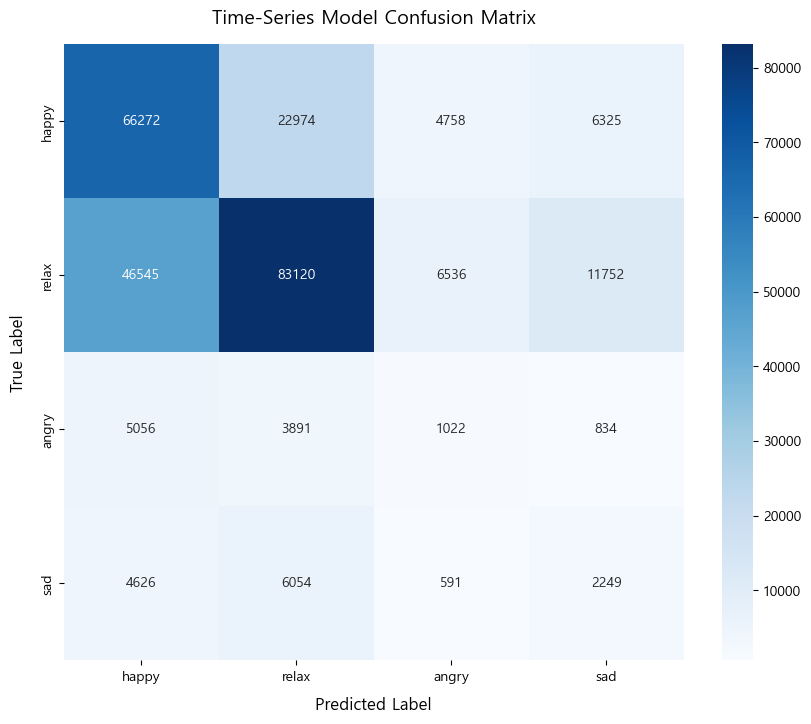

In [25]:

X_val_data = np.load("X_val_data.npy") # 검증용 X 저장 파일
y_val_data = np.load("y_val_data.npy") # 검증용 y 저장 파일

val_dataset = TensorDataset(torch.tensor(X_val_data, dtype=torch.float32), 
                            torch.tensor(y_val_data, dtype=torch.long))
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_eval = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
model_eval.load_state_dict(torch.load("dog_emotion_lstm_final6.pth"))
model_eval = model_eval.to(device)
model_eval.eval()

criterion = nn.CrossEntropyLoss()

total_val_loss = 0.0
correct = 0
total = 0

# 혼동 행렬을 위해 예측값과 실제값을 저장할 리스트 초기화
all_preds = []
all_targets = []

print("\n 시계열 모델 검증 시작...")
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model_eval(batch_X)
        loss = criterion(outputs, batch_y)
        
        total_val_loss += loss.item() * batch_X.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        # 정답 및 예측값 수집 (CPU로 이동 및 numpy 변환)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

avg_val_loss = total_val_loss / total
accuracy = (correct / total) * 100

print("\n==============================================")
print(" 시계열 모델 검증 결과 리포트")
print(f" 총 검증 샘플 수: {total} 개")
print(f" 평균 검증 손실 (Val Loss): {avg_val_loss:.4f}")
print(f" 모델 최종 정확도 (Val Accuracy): {accuracy:.2f}%")
print("==============================================")


class_names = ["happy", "relax", "angry", "sad"]

print("\n📊 [클래스별 상세 평가지표 리포트]")
print(classification_report(all_targets, all_preds, target_names=class_names))

print("\n🎨 [혼동 행렬(Confusion Matrix) 시각화]")
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
# 한글 깨짐 방지 (필요 시 주석 해제하여 사용)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Time-Series Model Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.show()

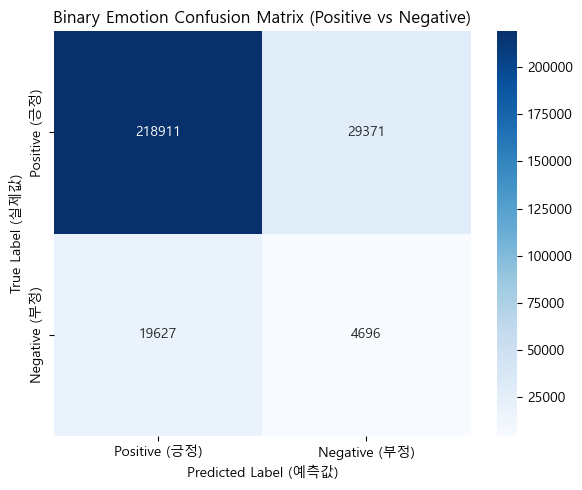

=== 병합된 혼동 행렬 수치 ===
실제 긍정 정답 (True Positive): 218,911개
긍정을 부정으로 오답 (False Negative): 29,371개
부정을 긍정으로 오답 (False Positive): 19,627개
실제 부정 정답 (True Negative): 4,696개


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. 화면에 표시된 4x4 혼동행렬 데이터 직접 입력 (행: 실제값, 열: 예측값)
# 순서: [행복/즐거움, 편안/안정, 화남/불쾌, 불안/슬픔]
cm_4x4 = np.array(
    [
        [66272, 22974, 4758, 6325],  # 실제 행복/즐거움
        [46545, 83120, 6536, 11752],  # 실제 편안/안정
        [5056, 3891, 1022, 834],  # 실제 화남/불쾌
        [4626, 6054, 591, 2249],  # 실제 불안/슬픔
    ]
)

# 2. 긍정(0, 1번 인덱스)과 부정(2, 3번 인덱스)으로 병합
cm_2x2 = np.zeros((2, 2), dtype=int)

# [[긍정->긍정, 긍정->부정],
#  [부정->긍정, 부정->부정]]
cm_2x2[0, 0] = cm_4x4[0:2, 0:2].sum()  # 실제 긍정, 예측 긍정
cm_2x2[0, 1] = cm_4x4[0:2, 2:4].sum()  # 실제 긍정, 예측 부정
cm_2x2[1, 0] = cm_4x4[2:4, 0:2].sum()  # 실제 부정, 예측 긍정
cm_2x2[1, 1] = cm_4x4[2:4, 2:4].sum()  # 실제 부정, 예측 부정

# 3. 혼동행렬 시각화
plt.figure(figsize=(6, 5))
labels = ["Positive (긍정)", "Negative (부정)"]

# annot=True로 숫자 표시, fmt='d'로 정수형태 표현
sns.heatmap(
    cm_2x2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title("Binary Emotion Confusion Matrix (Positive vs Negative)")
plt.xlabel("Predicted Label (예측값)")
plt.ylabel("True Label (실제값)")
plt.tight_layout()
plt.show()

# 4. 수치 요약 출력
print("=== 병합된 혼동 행렬 수치 ===")
print(f"실제 긍정 정답 (True Positive): {cm_2x2[0, 0]:,}개")
print(f"긍정을 부정으로 오답 (False Negative): {cm_2x2[0, 1]:,}개")
print(f"부정을 긍정으로 오답 (False Positive): {cm_2x2[1, 0]:,}개")
print(f"실제 부정 정답 (True Negative): {cm_2x2[1, 1]:,}개")

In [3]:
import os
import glob
import json
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

class DogEmotionLSTMClassifier(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=128, num_layers=2, num_classes=4):
        super(DogEmotionLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Input_Dim]
        lstm_out, _ = self.lstm(x)
        # 시퀀스의 마지막 타임스텝 데이터 추출
        last_out = lstm_out[:, -1, :] 
        return self.fc(last_out)

In [22]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO

# 1. 저장된 결합 모델들 로드 (GPU/CUDA 연동 설정 포함)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 추론에 장치 적용 완료: {device}")

# YOLOv8 Pose 모델 로드
yolo_pose_model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")

# 새로 학습된 LSTM 시계열 감정 분류 모델 구조 선언 및 가중치 파일 로드
# (주의: DogEmotionLSTMClassifier 클래스가 이전 셀에 미리 선언되어 있어야 합니다)
emotion_model = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
emotion_model.load_state_dict(torch.load("dog_emotion_lstm_final7.pth", map_location=device))
emotion_model = emotion_model.to(device)
emotion_model.eval() # 추론(Evaluation) 모드로 고정

# 🌟 현재 학습 규칙과 100% 일치하도록 매핑 라벨 한글화 및 클래스 역정의
class_names = {0: "happy", 1: "relax", 2: "angry", 3: "sad"}

# 2. 분석용 원본 동영상 지정 및 출력 설정
input_video = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\KakaoTalk_20260608_171616442.mp4"
cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print(f"❌ 동영상을 열 수 없습니다. 경로를 확인해 주세요: {input_video}")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\output\KakaoTalk_20260608_171616442.mp4", fourcc, fps, (width, height))

    # 🌟 [시계열 핵심] 실시간 프레임의 관절 좌표를 최대 30개까지 누적할 버퍼(Queue 역할)
    SEQUENCE_LEN = 30
    frame_buffer = []

    print("🎬 통합 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # [Stage 1] YOLOv8 Pose 모델 실행
        results = yolo_pose_model.predict(source=frame, conf=0.5, verbose=False)
        annotated_frame = results[0].plot() # 개별 관절 및 연결선 드로잉 기본 적용
        
        # 관절 정보 추출 여부 확인
        if results[0].keypoints is not None and len(results[0].keypoints.data) > 0:
            # 모델이 포착한 첫 번째 객체의 15개 키포인트 배열 [15, 3] 추출
            keypoints = results[0].keypoints.data[0].cpu().numpy()
            
            # x, y 좌표값만 분리 및 평탄화 (30차원 벡터)
            kp_xy = keypoints[:, :2].flatten()
            
            # 학습 단계와 동일한 정규화 스케일 적용
            kp_xy_scaled = kp_xy / 2000.0 
            
            # 🌟 [슬라이딩 윈도우] 버퍼에 현재 프레임 좌표 누적
            frame_buffer.append(kp_xy_scaled)
            
            # 버퍼 크기가 30개를 초과하면 가장 오래된(처음 들어왔던) 프레임 제거
            if len(frame_buffer) > SEQUENCE_LEN:
                frame_buffer.pop(0)
                
            # 🌟 버퍼에 최소 30프레임(시계열 조건)이 꽉 찼을 때만 LSTM 감정 분석 수행
            if len(frame_buffer) == SEQUENCE_LEN:
                # 리스트를 파이토치 텐서 형태로 변환 [30, 30] -> 모델 입력용 배치 차원 추가 [1, 30, 30]
                kp_tensor = torch.tensor(np.array(frame_buffer), dtype=torch.float32).to(device)
                
                # [Stage 2] PyTorch LSTM 신경망 예측 수행
                with torch.no_grad():
                    kp_tensor = kp_tensor.unsqueeze(0)
                    emotion_outputs = emotion_model(kp_tensor)
                    
                    prediction = torch.argmax(emotion_outputs, dim=1).item()
                    confidence = torch.softmax(emotion_outputs, dim=1)[0][prediction].item()
                    
                emotion_text = f"Emotion: {class_names.get(prediction, 'Unknown')} ({confidence*100:.1f}%)"
                
                # 3. 화면 바운딩 박스 내 좌측 하단 영역에 감정 분석 텍스트 시각화 오버레이
                if results[0].boxes is not None and len(results[0].boxes.xyxy) > 0:
                    box = results[0].boxes.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, box)
                    
                    # 텍스트 백그라운드 사각형 박스 및 한글 정보 렌더링 (좌측 하단 기준)
                    # y2가 바운딩 박스 최하단이므로, 안쪽으로 들여보내기 위해 y2-35부터 y2까지 배경을 그립니다.
                    cv2.rectangle(annotated_frame, (x1, y2 - 35), (x1 + 350, y2), (0, 165, 255), -1) # 주황빛 배경
                    
                    # 텍스트가 배경 박스 중앙에 위치하도록 y 좌표를 y2 - 10으로 지정합니다.
                    cv2.putText(annotated_frame, emotion_text, (x1 + 8, y2 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        else:
            # 만약 중간에 개를 일시적으로 놓치면 프레임의 연속성이 끊기므로 버퍼를 비워줍니다.
            frame_buffer.clear()

        # 조합된 프레임을 결과 동영상 파일에 라이팅
        out.write(annotated_frame)

    cap.release()
    out.release()
    print("🎉 LSTM 시계열 감정 분류 하이브리드 동영상 저장 완료")

🚀 추론에 장치 적용 완료: cuda
🎬 통합 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...
🎉 LSTM 시계열 감정 분류 하이브리드 동영상 저장 완료


In [15]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from tqdm import tqdm

# 환경 설정
CSV_PATH = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\drive-download-20260605T053127Z-3-001"
AUDIO_DIR = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\drive-download-20260605T053127Z-3-001"
BATCH_SIZE = 4        # 🚨 Wav2Vec2는 모델이 크므로 메모리 에러(OOM) 방지를 위해 배치 사이즈를 작게 잡습니다.
EPOCHS = 5
LEARNING_RATE = 2e-5  # 전이학습(Fine-tuning)을 위해 작은 러닝레이트를 사용합니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torchaudio.set_audio_backend("soundfile")

Using device: cuda


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_7492\1536050461.py:20: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.set_audio_backend("soundfile")
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\torchaudio\_internal\module_utils.py:71: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  return func(*args, **kwargs)


In [25]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.io import wavfile
import torch.nn.functional as F

class DogWav2VecDataset(Dataset):
    def __init__(self, csv_file, audio_dir, target_sr=16000, duration=3):
        self.df = pd.read_csv(csv_file)
        self.audio_dir = audio_dir
        self.target_sr = target_sr
        self.num_samples = target_sr * duration  # 16000 * 3 = 48000 샘플
        
        # 감정 클래스 매핑 (4~5개 클래스 설계에 맞춤)
        self.label_map = {
            ('high', 'positive'): 0, ('medium', 'positive'): 0,   # Happy/Excited
            ('high', 'negative'): 1, ('medium', 'negative'): 1,   # Angry/Fearful
            ('low', 'negative'): 2,                                # Sad/Bored
            ('low', 'positive'): 3,                                # Calm/Relaxed
            ('high', 'neutral'): 4, ('medium', 'neutral'): 4, ('low', 'neutral'): 4 # Neutral
        }

    def __len__(self):
        return len(self.df)

    def _process_label(self, row):
        arousal = str(row['arousal']).lower().strip()
        valence = str(row['valence']).lower().strip()
        return self.label_map.get((arousal, valence), 4)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_id = str(row['audio_id'])
        
        # 확장자 방어 코드
        if not audio_id.endswith('.wav'):
            audio_id += '.wav'
            
        audio_path = os.path.join(self.audio_dir, audio_id)
        
        # 1. torchaudio 대신 scipy로 안전하게 파일 읽기
        sr, data = wavfile.read(audio_path)
        
        # 2. 넘파이 배열을 파이토치 텐서로 변환 (기본 형태: [샘플수, 채널수])
        waveform = torch.tensor(data, dtype=torch.float32)
        
        # 스테레오 음성인 경우 평균을 내어 모노[샘플수]로 변환
        if waveform.ndim > 1:
            waveform = torch.mean(waveform, dim=1)
            
        # 정수형 오디오 데이터를 -1.0 ~ 1.0 범위로 정규화
        if data.dtype == 'int16':
            waveform = waveform / 32768.0
        elif data.dtype == 'int32':
            waveform = waveform / 2147483648.0
            
        # 3. 간단한 선형 보간(Linear Interpolation)으로 16kHz 리샘플링 구현 (torchaudio 변환기 대체)
        if sr != self.target_sr:
            # F.interpolate를 쓰기 위해 [1, 1, 샘플수] 형태로 언스퀴즈
            waveform = waveform.unsqueeze(0).unsqueeze(0)
            new_len = int(waveform.shape[-1] * (self.target_sr / sr))
            waveform = F.interpolate(waveform, size=new_len, mode='linear', align_corners=False)
            waveform = waveform.squeeze(0).squeeze(0) # 다시 [샘플수]로 복원
            
        # 4. 길이 맞추기 (3초 고정 -> 48000 샘플)
        if waveform.shape[0] > self.num_samples:
            waveform = waveform[:self.num_samples]
        elif waveform.shape[0] < self.num_samples:
            pad_size = self.num_samples - waveform.shape[0]
            waveform = F.pad(waveform, (0, pad_size))
            
        # 5. 라벨링
        label = self._process_label(row)
        
        return waveform, torch.tensor(label, dtype=torch.long)

In [26]:
class Wav2Vec2ClassificationModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # 사전학습된 기본 Wav2Vec2 모델 로드
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        
        # 분류기 레이어 설정 (Wav2Vec2의 히든 사이즈는 기본 768입니다)
        self.classifier = nn.Linear(768, num_classes)
        
    def forward(self, x):
        # x shape: [batch_size, sequence_length]
        outputs = self.wav2vec2(x)
        
        # 전체 시퀀스의 특징을 평균(Mean Pooling)내어 하나의 벡터로 만듭니다.
        hidden_states = outputs.last_hidden_state
        pooled_output = torch.mean(hidden_states, dim=1)
        
        # 최종 분류 수행
        logits = self.classifier(pooled_output)
        return logits

In [27]:
# 1. 데이터로더 설정
train_dataset = DogWav2VecDataset(csv_file=CSV_PATH+"\\train.csv", audio_dir=AUDIO_DIR+"\\train")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. 모델 및 학습 요소 선언
model = Wav2Vec2ClassificationModel(num_classes=5).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# 3. Training Loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Forward
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 통계
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        progress_bar.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    print(f"▶ Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

# 모델 저장
torch.save(model.state_dict(), "dog_emotion_wav2vec2.pth")
print("Wav2Vec2 Model saved!")

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\transformers\configuration_utils.py:365: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN t

▶ Epoch [1/5] Loss: 1.4558 | Acc: 33.92%


Epoch [2/5]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:52<00:00,  5.76it/s, loss=1.09]


▶ Epoch [2/5] Loss: 1.4437 | Acc: 33.00%


Epoch [3/5]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:52<00:00,  5.73it/s, loss=1.4]


▶ Epoch [3/5] Loss: 1.4393 | Acc: 33.75%


Epoch [4/5]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:52<00:00,  5.66it/s, loss=1.45]


▶ Epoch [4/5] Loss: 1.4389 | Acc: 34.08%


Epoch [5/5]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:52<00:00,  5.71it/s, loss=1.39]


▶ Epoch [5/5] Loss: 1.4388 | Acc: 31.83%
Wav2Vec2 Model saved!


In [28]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- 📌 검증 환경 설정 (본인의 경로에 맞게 수정) 📌 ---
VAL_CSV_PATH = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\drive-download-20260605T053127Z-3-001\test.csv"         # 검증용 CSV 파일 경로 (없다면 train.csv로 우선 테스트 가능)
VAL_AUDIO_DIR = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\drive-download-20260605T053127Z-3-001\test"          # 검증용 wav 파일 폴더 경로
BATCH_SIZE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 검증 데이터로더 준비 (앞서 정의한 Scipy 버전 Dataset 사용)
val_dataset = DogWav2VecDataset(csv_file=VAL_CSV_PATH, audio_dir=VAL_AUDIO_DIR)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. 저장된 모델 로드
model = Wav2Vec2ClassificationModel(num_classes=5).to(DEVICE)
model.load_state_dict(torch.load("dog_emotion_wav2vec2.pth", map_location=DEVICE))
model.eval()

criterion = nn.CrossEntropyLoss()

# 3. 검증 루프 실행
val_loss = 0.0
correct = 0
total = 0

print("검증을 시작합니다...")
with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리 절약)
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # 예측
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 통계 계산
        val_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_loss = val_loss / total
final_acc = (correct / total) * 100

print("\n================ 검증 결과 ================")
print(f"▶ Validation Loss: {final_loss:.4f}")
print(f"▶ Validation Accuracy: {final_acc:.2f}%")
print("===========================================")

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\transformers\configuration_utils.py:365: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN t

검증을 시작합니다...


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.05it/s]


================ 검증 결과 ================
▶ Validation Loss: 1.5737
▶ Validation Accuracy: 22.50%


In [23]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO

# 1. 저장된 결합 모델들 로드 (GPU/CUDA 연동 설정 포함)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 추론에 장치 적용 완료: {device}")

# YOLOv8 Pose 모델 로드
yolo_pose_model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")

# 새로 학습된 LSTM 시계열 감정 분류 모델 구조 선언 및 가중치 파일 로드
emotion_model = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
emotion_model.load_state_dict(torch.load("dog_emotion_lstm_final7.pth", map_location=device))
emotion_model = emotion_model.to(device)
emotion_model.eval() # 추론(Evaluation) 모드로 고정

# 매핑 라벨 및 클래스 역정의
class_names = {0: "happy", 1: "relax", 2: "angry", 3: "sad"}

# 2. 분석용 원본 동영상 지정 및 출력 설정
input_video = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\KakaoTalk_20260608_171616442.mp4"
cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print(f"❌ 동영상을 열 수 없습니다. 경로를 확인해 주세요: {input_video}")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\output\KakaoTalk_20260608_171616442.mp4", fourcc, fps, (width, height))

    # [시계열 핵심] 실시간 프레임의 관절 좌표를 최대 30개까지 누적할 버퍼
    SEQUENCE_LEN = 30
    frame_buffer = []

    # 🌟 [추가] 감정 지속시간 유지를 위한 제어 변수 초기화
    active_emotion_text = ""      # 현재 화면에 최종 표시될 텍스트
    emotion_hold_counter = 0      # 특정 감정을 유지할 남은 프레임 수

    print("🎬 통합 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # [Stage 1] YOLOv8 Pose 모델 실행
        results = yolo_pose_model.predict(source=frame, conf=0.5, verbose=False)
        annotated_frame = results[0].plot() # 개별 관절 및 연결선 드로잉 기본 적용
        
        is_dog_valid = False
        if results[0].boxes is not None and len(results[0].boxes.conf) > 0:
            dog_conf = results[0].boxes.conf[0].item() # 첫 번째 객체의 YOLO 신뢰도
            if dog_conf >= 0.75:
                is_dog_valid = True

        if is_dog_valid and results[0].keypoints is not None and len(results[0].keypoints.data) > 0:
            # 모델이 포착한 첫 번째 객체의 15개 키포인트 배열 [15, 3] 추출
            keypoints = results[0].keypoints.data[0].cpu().numpy()
            
            # x, y 좌표값만 분리 및 평탄화 (30차원 벡터)
            kp_xy = keypoints[:, :2].flatten()
            
            # 학습 단계와 동일한 정규화 스케일 적용
            kp_xy_scaled = kp_xy / 2000.0 
            
            # 버퍼에 현재 프레임 좌표 누적
            frame_buffer.append(kp_xy_scaled)
            
            # 버퍼 크기가 30개를 초과하면 가장 오래된 프레임 제거
            if len(frame_buffer) > SEQUENCE_LEN:
                frame_buffer.pop(0)
                
            # 버퍼에 최소 30프레임이 꽉 찼을 때만 LSTM 감정 분석 수행
            if len(frame_buffer) == SEQUENCE_LEN:
                # 리스트를 파이토치 텐서 형태로 변환
                kp_tensor = torch.tensor(np.array(frame_buffer), dtype=torch.float32).to(device)
                
                # [Stage 2] PyTorch LSTM 신경망 예측 수행
                with torch.no_grad():
                    kp_tensor = kp_tensor.unsqueeze(0)
                    emotion_outputs = emotion_model(kp_tensor)
                    
                    prediction = torch.argmax(emotion_outputs, dim=1).item()
                    confidence = torch.softmax(emotion_outputs, dim=1)[0][prediction].item()
                    
                predicted_emotion = class_names.get(prediction, 'Unknown')
                new_emotion_text = f"Emotion: {predicted_emotion} ({confidence*100:.1f}%)"
                
                # 🌟 [추가] 감정 홀드 타임(지속성) 로직 제어
                if emotion_hold_counter > 0:
                    # 아직 유지 카운트가 남았다면 기존 화면 텍스트를 유지하고 카운트 차감
                    emotion_hold_counter -= 1
                else:
                    # 카운트가 만료되었다면 현재 예측한 감정으로 텍스트 업데이트
                    active_emotion_text = new_emotion_text
                    
                    # 만약 새로 검출된 감정이 sad 또는 angry라면, 일정 프레임 동안 화면 고정 설정
                    if predicted_emotion.lower() in ['sad', 'angry']:
                        emotion_hold_counter = 50   
                        
                # 3. 화면 바운딩 박스 내 좌측 하단 영역에 감정 분석 텍스트 시각화 오버레이
                if results[0].boxes is not None and len(results[0].boxes.xyxy) > 0:
                    box = results[0].boxes.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, box)
                    
                    # 텍스트 백그라운드 사각형 박스 렌더링 (좌측 하단 기준)
                    cv2.rectangle(annotated_frame, (x1, y2 - 35), (x1 + 350, y2), (0, 165, 255), -1) # 주황빛 배경
                    
                    # 🌟 [수정] 실시간 갱신되는 텍스트 대신 홀드 처리가 반영된 active_emotion_text를 렌더링합니다.
                    if active_emotion_text:
                        cv2.putText(annotated_frame, active_emotion_text, (x1 + 8, y2 - 10), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        else:
            # 개를 일시적으로 놓치거나, 확률이 0.6 미만으로 떨어지면 연속성이 끊기므로 버퍼를 초기화하고 홀드 카운트도 리셋합니다.
            frame_buffer.clear()
            emotion_hold_counter = 0
            active_emotion_text = ""

        # 조합된 프레임을 결과 동영상 파일에 라이팅
        out.write(annotated_frame)

    cap.release()
    out.release()
    print("🎉 LSTM 시계열 감정 분류 하이브리드 동영상 저장 완료")

🚀 추론에 장치 적용 완료: cuda
🎬 통합 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...
🎉 LSTM 시계열 감정 분류 하이브리드 동영상 저장 완료


In [14]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO

# 1. 저장된 결합 모델들 로드 (GPU/CUDA 연동 설정 포함)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 추론에 장치 적용 완료: {device}")

# YOLOv8 Pose 모델 로드
yolo_pose_model = YOLO("../runs/pose/Dog_Pose_Project/weights/best.pt")

# 새로 학습된 LSTM 시계열 감정 분류 모델 구조 선언 및 가중치 파일 로드
emotion_model = DogEmotionLSTMClassifier(input_dim=30, hidden_dim=128, num_layers=2, num_classes=4)
emotion_model.load_state_dict(torch.load("dog_emotion_lstm_final5.pth", map_location=device))
emotion_model = emotion_model.to(device)
emotion_model.eval()

# 매핑 라벨 및 클래스 역정의
class_names = {0: "happy", 1: "relax", 2: "angry", 3: "sad"}

# 2. 분석용 원본 동영상 지정 및 출력 설정
input_video = r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\데이터\[세나개] 용산구에 개 상전, '카푸' 황후 모시기! 예고편.mp4"
cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print(f"❌ 동영상을 열 수 없습니다. 경로를 확인해 주세요: {input_video}")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(r"C:\Users\Win11Pro\Documents\KDT13\miniproject\08_1조_개\output\[세나개] 용산구에 개 상전, '카푸' 황후 모시기! 예고편.mp4", fourcc, fps, (width, height))

    SEQUENCE_LEN = 30
    
    # 🌟 [다중 객체 핵심] 각 개의 고유 ID별로 시계열 버퍼와 상태를 격리 관리하는 딕셔너리 구조
    multi_frame_buffers = {}       # 예: { id_1: [kp, kp, ...], id_2: [...] }
    multi_active_emotions = {}     # 예: { id_1: "Emotion: happy", id_2: "Emotion: sad" }
    multi_hold_counters = {}       # 예: { id_1: 15, id_2: 0 }

    print("🎬 다중 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # 🌟 [변경 1] predict 대신 track을 사용하고 persist=True를 주어 프레임 간 객체 고유 ID를 추적합니다.
        results = yolo_pose_model.track(source=frame, conf=0.5, persist=True, verbose=False)
        annotated_frame = frame.copy() # 박스를 직접 커스텀 드로잉하기 위해 프레임 복사
        
        # 현재 프레임에서 검출된 객체 ID 목록을 기록하여, 화면에서 사라진 개들의 버퍼를 지우는 데 사용합니다.
        current_frame_ids = []

        # 바운딩 박스와 키포인트, ID 데이터가 모두 존재하는지 확인
        if (results[0].boxes is not None and results[0].boxes.id is not None and 
            results[0].keypoints is not None and len(results[0].keypoints.data) > 0):
            
            boxes = results[0].boxes.xyxy.cpu().numpy()
            confs = results[0].boxes.conf.cpu().numpy()
            track_ids = results[0].boxes.id.int().cpu().numpy()
            keypoints_all = results[0].keypoints.data.cpu().numpy()

            # 🌟 [변경 2] 화면에 검출된 '모든' 개들을 돌면서 루프 연산을 수행합니다.
            for idx, track_id in enumerate(track_ids):
                current_frame_ids.append(track_id)
                
                # YOLO 신뢰도가 0.6 미만인 개체는 무시합니다.
                if confs[idx] < 0.6:
                    continue
                
                # 해당 객체의 바운딩 박스와 관절 정보 추출
                x1, y1, x2, y2 = map(int, boxes[idx])
                keypoints = keypoints_all[idx] # [15, 3] 개의 관절 정보
                
                # 기본 YOLO 관절/스켈레톤선 화면에 시각화
                yolo_pose_model.predictor.annotator = None 
                # (간단하게 바운딩 박스만 우선 직접 그립니다)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # 30차원 키포인트 벡터 정규화 및 가공
                kp_xy = keypoints[:, :2].flatten()
                kp_xy_scaled = kp_xy / 2000.0 
                
                # 🌟 [변경 3] 해당 Track ID를 위한 버퍼 및 변수가 없다면 새로 생성합니다.
                if track_id not in multi_frame_buffers:
                    multi_frame_buffers[track_id] = []
                    multi_active_emotions[track_id] = "Analyzing..."
                    multi_hold_counters[track_id] = 0
                
                # 개별 버퍼에 현재 프레임 좌표 누적
                multi_frame_buffers[track_id].append(kp_xy_scaled)
                if len(multi_frame_buffers[track_id]) > SEQUENCE_LEN:
                    multi_frame_buffers[track_id].pop(0)
                    
                # 30프레임 시계열이 꽉 찬 경우에만 독립적으로 LSTM 예측 실행
                if len(multi_frame_buffers[track_id]) == SEQUENCE_LEN:
                    kp_tensor = torch.tensor(np.array(multi_frame_buffers[track_id]), dtype=torch.float32).to(device)
                    
                    with torch.no_grad():
                        kp_tensor = kp_tensor.unsqueeze(0)
                        emotion_outputs = emotion_model(kp_tensor)
                        
                        prediction = torch.argmax(emotion_outputs, dim=1).item()
                        confidence = torch.softmax(emotion_outputs, dim=1)[0][prediction].item()
                        
                    predicted_emotion = class_names.get(prediction, 'Unknown')
                    new_emotion_text = f"ID {track_id}: {predicted_emotion} ({confidence*100:.1f}%)"
                    
                    # 🌟 [변경 4] 개별 객체별 독립된 홀드 타임(지속시간) 로직 적용
                    if multi_hold_counters[track_id] > 0:
                        multi_hold_counters[track_id] -= 1
                    else:
                        multi_active_emotions[track_id] = new_emotion_text
                        if predicted_emotion.lower() in ['sad', 'angry']:
                            multi_hold_counters[track_id] = 30 # 30프레임 홀드
                
                # 🌟 [변경 5] 각 마리의 바운딩 박스 내 좌측 하단에 개별 감정 텍스트 오버레이
                if multi_active_emotions[track_id]:
                    # ID 텍스트 구분을 위해 배경 영역 확장 및 렌더링
                    cv2.rectangle(annotated_frame, (x1, y2 - 35), (x1 + 280, y2), (0, 165, 255), -1) # 주황색 배경
                    cv2.putText(annotated_frame, multi_active_emotions[track_id], (x1 + 8, y2 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

        # 🌟 메모리 관리: 현재 프레임에 잡히지 않고 화면에서 완전히 빠져나간 ID들의 버퍼 및 상태 초기화
        dead_ids = [tid for tid in multi_frame_buffers.keys() if tid not in current_frame_ids]
        for d_id in dead_ids:
            del multi_frame_buffers[d_id]
            del multi_active_emotions[d_id]
            del multi_hold_counters[d_id]

        # 조합된 프레임을 결과 동영상 파일에 라이팅
        out.write(annotated_frame)

    cap.release()
    out.release()
    print("🎉 다중 객체 트래킹 기반 LSTM 시계열 감정 분류 동영상 저장 완료")

🚀 추론에 장치 적용 완료: cuda
🎬 다중 포즈-LSTM 시계열 감정 분석 모델 실시간 추론 진행 중...
WARNING not enough matching points
🎉 다중 객체 트래킹 기반 LSTM 시계열 감정 분류 동영상 저장 완료
